In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer 
import warnings
warnings.filterwarnings('ignore')

# 1. Load the Pristine Dataset
df = pd.read_csv('D:/fakeReviewDetector/data/deberta_training_50k_PRISTINE.csv')
df['review_text'] = df['review_text'].astype(str)

# ---> THE FIX: Recalculate word_count on the fly <---
df['word_count'] = df['review_text'].str.split().str.len()

# Set visual style
sns.set_theme(style="whitegrid")
colors = ["#2ecc71", "#e74c3c"] # Green for Genuine, Red for Fake

print(f"Dataset Loaded. Total Rows: {len(df)}")

Dataset Loaded. Total Rows: 36832


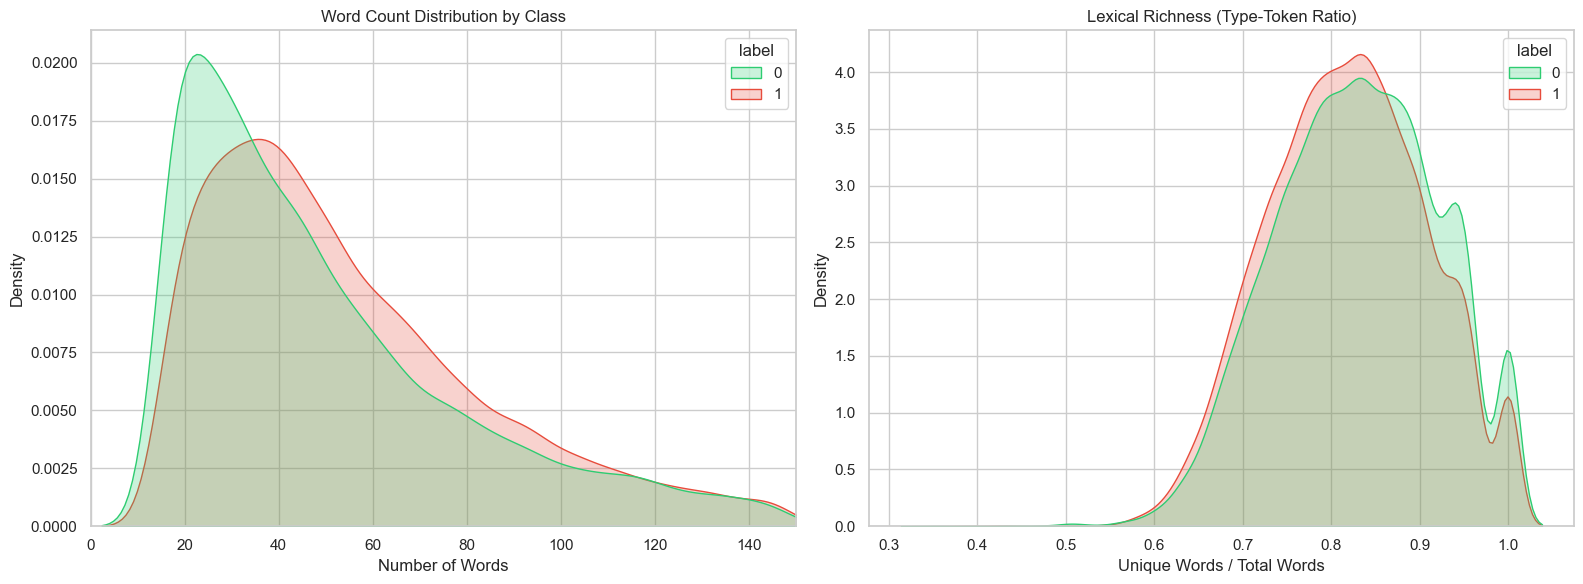

In [2]:
# ==========================================
# 2. LENGTH & COMPLEXITY DISTRIBUTION
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Word Count KDE
sns.kdeplot(data=df, x='word_count', hue='label', fill=True, palette=colors, ax=axes[0], common_norm=False)
axes[0].set_title('Word Count Distribution by Class')
axes[0].set_xlabel('Number of Words')
axes[0].set_xlim(0, 150)

# Lexical Richness (Type-Token Ratio)
# TTR = (Unique Words) / (Total Words). High TTR = rich vocabulary. Low TTR = repetitive.
def calculate_ttr(text):
    tokens = text.lower().split()
    if len(tokens) == 0: return 0
    return len(set(tokens)) / len(tokens)

df['ttr'] = df['review_text'].apply(calculate_ttr)

sns.kdeplot(data=df, x='ttr', hue='label', fill=True, palette=colors, ax=axes[1], common_norm=False)
axes[1].set_title('Lexical Richness (Type-Token Ratio)')
axes[1].set_xlabel('Unique Words / Total Words')

plt.tight_layout()
plt.show()

Extracting N-Grams (This might take a few seconds)...
Generating Bigram Plots...


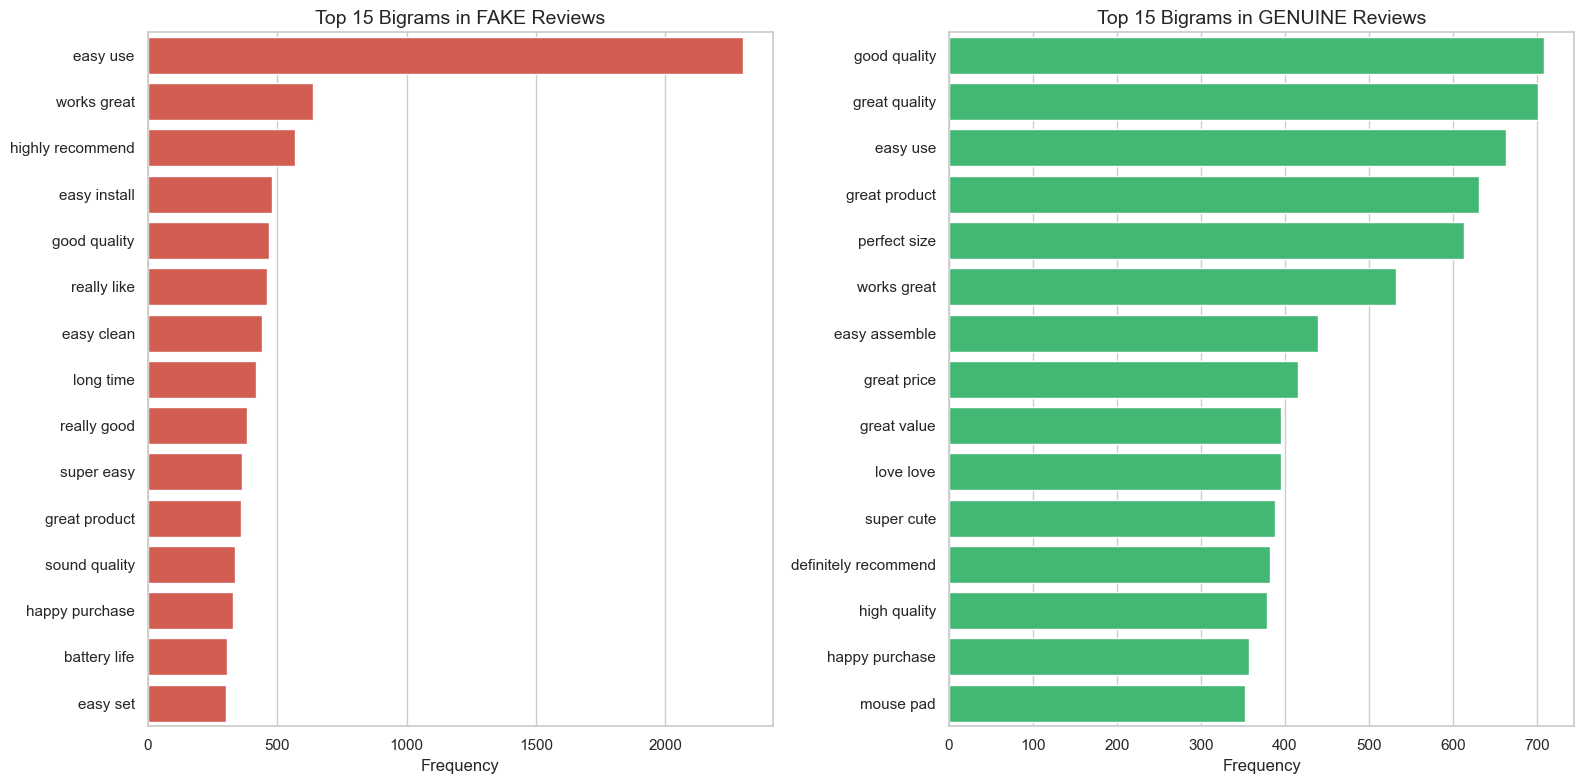

In [5]:
# ==========================================
# 4. VISUALIZATION: N-GRAM ANALYSIS
# ==========================================
print("Extracting N-Grams (This might take a few seconds)...")
def get_top_ngrams(corpus, n=None, ngram_range=(2,2)):
    vec = CountVectorizer(stop_words='english', ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

fake_reviews = df[df['label'] == 1]['review_text']
genuine_reviews = df[df['label'] == 0]['review_text']

top_fake_bigrams = get_top_ngrams(fake_reviews, n=15)
top_gen_bigrams = get_top_ngrams(genuine_reviews, n=15)

print("Generating Bigram Plots...")
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Fake Bigrams
sns.barplot(x=[val[1] for val in top_fake_bigrams], y=[val[0] for val in top_fake_bigrams], ax=axes[0], color=colors[1])
axes[0].set_title('Top 15 Bigrams in FAKE Reviews', fontsize=14)
axes[0].set_xlabel('Frequency', fontsize=12)

# Genuine Bigrams
sns.barplot(x=[val[1] for val in top_gen_bigrams], y=[val[0] for val in top_gen_bigrams], ax=axes[1], color=colors[0])
axes[1].set_title('Top 15 Bigrams in GENUINE Reviews', fontsize=14)
axes[1].set_xlabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

In [3]:
# ==========================================
# 4. SENTIMENT/RATING CHECK (Verifying Parity)
# ==========================================
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='review_rating', hue='label', palette=colors)
plt.title('Verification of Star Rating Parity')
plt.xlabel('Star Rating')
plt.ylabel('Count')
plt.show()

ValueError: Could not interpret value `review_rating` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x500 with 0 Axes>